In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
import sklearn
import statsmodels

print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("scipy:", scipy.__version__)
print("scikit-learn:", sklearn.__version__)
print("statsmodels:", statsmodels.__version__)  

pandas: 3.0.3
numpy: 2.5.1
scipy: 1.18.1
scikit-learn: 1.9.0
statsmodels: 0.15.0


In [3]:
import os

# Update this path to ma
DATA_PATH = r"C:\Users\uGwane\Documents\uGwane-2026\Kaggle Datasets\Brazilian E-Commerce Public Dataset by Olist\clean_data"

orders = pd.read_csv(os.path.join(DATA_PATH, "orders_clean.csv"))
reviews = pd.read_csv(os.path.join(DATA_PATH, "order_reviews_clean.csv"))

print("orders shape:", orders.shape)
print("reviews shape:", reviews.shape)

orders.head()

orders shape: (99441, 12)
reviews shape: (99224, 8)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_date_missing_flag,approval_date_suspicious_flag,delivery_time_days,extreme_delivery_delay_flag
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,False,False,8.0,False
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,False,False,13.0,False
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,False,False,9.0,False
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,False,False,13.0,False
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,False,False,2.0,False


In [4]:
# Convert date/timestamp columns to datetime
date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col], errors="coerce")

# Merge orders with reviews
orders_reviews = orders.merge(reviews, on="order_id", how="inner")

print("merged shape:", orders_reviews.shape)
print("\ndtypes check:")
print(orders_reviews[date_cols].dtypes)

orders_reviews[["order_id", "delivery_time_days", "review_score", "extreme_delivery_delay_flag"]].head()


merged shape: (99224, 19)

dtypes check:
order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object


,order_id,delivery_time_days,review_score,extreme_delivery_delay_flag
0,e481f51cbdc54678b7cc49136f2d6af7,8.0,4,False
1,53cdb2fc8bc7dce0b6741e2150273451,13.0,4,False
2,47770eb9100c2d0c44946d9cf07ec65d,9.0,5,False
3,949d5b44dbf5de918fe9c16f97b45f8a,13.0,5,False
4,ad21c59c0840e6cb83a9ceb5573f8159,2.0,5,False


In [5]:
print("Missing delivery_time_days:", orders_reviews["delivery_time_days"].isna().sum())
print("Missing review_score:", orders_reviews["review_score"].isna().sum())
print("\nOrder status breakdown for missing delivery_time_days:")
print(orders_reviews[orders_reviews["delivery_time_days"].isna()]["order_status"].value_counts())

# Create analysis-ready subset: drop rows with missing delivery_time_days
stats_df = orders_reviews.dropna(subset=["delivery_time_days", "review_score"]).copy()
print("\nAnalysis-ready shape:", stats_df.shape)


Missing delivery_time_days: 2865
Missing review_score: 0

Order status breakdown for missing delivery_time_days:
order_status
shipped        1043
canceled        603
unavailable     597
invoiced        313
processing      296
delivered         8
created           3
approved          2
Name: count, dtype: int64

Analysis-ready shape: (96359, 19)


In [6]:
from scipy import stats

pearson_r, pearson_p = stats.pearsonr(stats_df["delivery_time_days"], stats_df["review_score"])
spearman_r, spearman_p = stats.spearmanr(stats_df["delivery_time_days"], stats_df["review_score"])

print(f"Pearson r:  {pearson_r:.4f}, p-value: {pearson_p:.2e}")
print(f"Spearman ρ: {spearman_r:.4f}, p-value: {spearman_p:.2e}")


Pearson r:  -0.3337, p-value: 0.00e+00
Spearman ρ: -0.2344, p-value: 0.00e+00


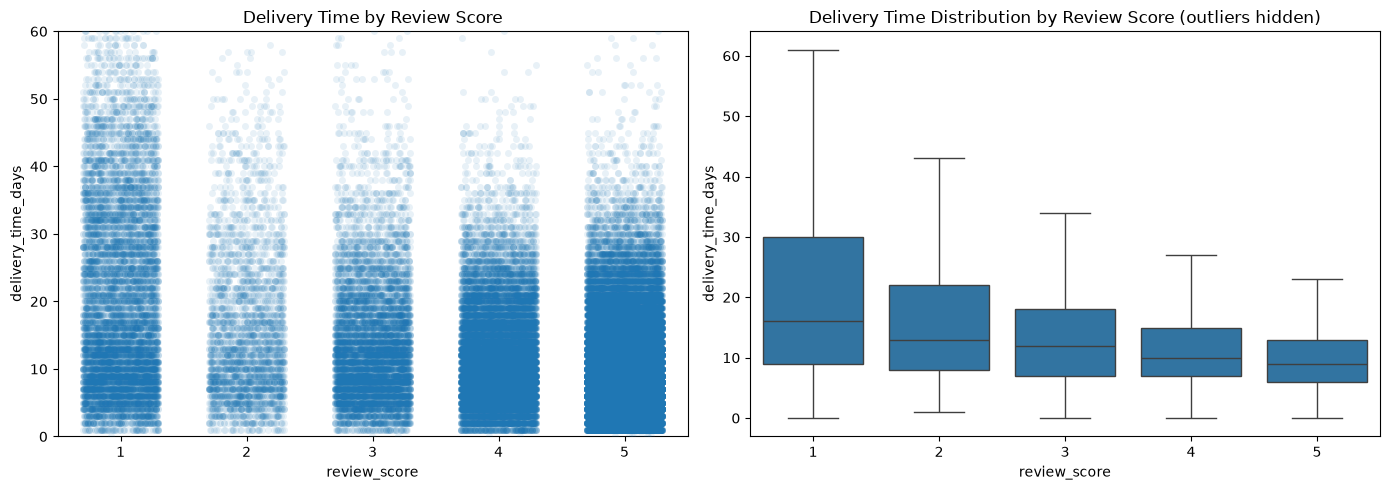

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter with jitter (review_score is discrete 1-5, so jitter helps see density)
sns.stripplot(data=stats_df, x="review_score", y="delivery_time_days", alpha=0.1, jitter=0.3, ax=axes[0])
axes[0].set_title("Delivery Time by Review Score")
axes[0].set_ylim(0, 60)  # cap extreme outliers for visibility

# Boxplot for a cleaner distributional view
sns.boxplot(data=stats_df, x="review_score", y="delivery_time_days", ax=axes[1], showfliers=False)
axes[1].set_title("Delivery Time Distribution by Review Score (outliers hidden)")

plt.tight_layout()
plt.show()


In [8]:
groups = [stats_df[stats_df["review_score"] == score]["delivery_time_days"].values 
          for score in sorted(stats_df["review_score"].unique())]

# One-way ANOVA
f_stat, anova_p = stats.f_oneway(*groups)
print(f"ANOVA F-statistic: {f_stat:.4f}, p-value: {anova_p:.2e}")

# Kruskal-Wallis (non-parametric alternative)
h_stat, kw_p = stats.kruskal(*groups)
print(f"Kruskal-Wallis H-statistic: {h_stat:.4f}, p-value: {kw_p:.2e}")


ANOVA F-statistic: 3137.5059, p-value: 0.00e+00
Kruskal-Wallis H-statistic: 6073.6652, p-value: 0.00e+00


In [9]:
levene_stat, levene_p = stats.levene(*groups)
print(f"Levene's statistic: {levene_stat:.4f}, p-value: {levene_p:.2e}")


Levene's statistic: 2535.9077, p-value: 0.00e+00


## Phase 1: Statistical Validation — Delivery Speed vs. Review Score

**Question:** Is there a statistically significant relationship between delivery 
time and customer review score, and how strong is it?

**Correlation:**
- Pearson r = -0.334 (p < 0.001) — moderate negative linear correlation
- Spearman ρ = -0.234 (p < 0.001) — weaker rank-based correlation, suggesting 
  the relationship isn't purely linear and is influenced by long-tail delivery outliers
- r² ≈ 0.11 — delivery time alone explains ~11% of variance in review score; 
  a real effect, but far from the only driver of satisfaction

**Group comparison (by review score, 1–5):**
- One-way ANOVA: F = 3137.51, p < 0.001
- Kruskal-Wallis: H = 6073.67, p < 0.001
- Levene's test for equal variance: p < 0.001 → **variances are significantly 
  unequal across groups**, violating ANOVA's core assumption. Kruskal-Wallis 
  is therefore the more reliable test here.

**Interpretation:** Median delivery time decreases steadily from 16 days 
(1-star reviews) to 9 days (5-star reviews), with 1-star reviews also showing 
the widest spread (IQR of ~21 days vs. ~7 days for 5-star). The relationship 
is monotonic and statistically robust, but effect size is moderate — delivery 
speed matters to customer satisfaction, but isn't the sole driver.

**Note on p-values:** All p-values reported as 0.00e+00 reflect floating-point 
underflow (values too small for Python to represent), not true zero — expected 
given the ~96K row sample size.


In [10]:
stats_df["shipping_tier"] = np.where(stats_df["delivery_time_days"] <= 7, "fast", "slow")

print(stats_df["shipping_tier"].value_counts())
print("\nMean review score by tier:")
print(stats_df.groupby("shipping_tier")["review_score"].mean())


shipping_tier
slow    62674
fast    33685
Name: count, dtype: int64

Mean review score by tier:
shipping_tier
fast    4.408223
slow    4.019753
Name: review_score, dtype: float64


In [11]:
fast_scores = stats_df[stats_df["shipping_tier"] == "fast"]["review_score"]
slow_scores = stats_df[stats_df["shipping_tier"] == "slow"]["review_score"]

# Welch's t-test (does NOT assume equal variances — safer default than Student's t-test)
t_stat, t_p = stats.ttest_ind(fast_scores, slow_scores, equal_var=False)

# Cohen's d effect size
mean_diff = fast_scores.mean() - slow_scores.mean()
pooled_std = np.sqrt((fast_scores.std()**2 + slow_scores.std()**2) / 2)
cohens_d = mean_diff / pooled_std

print(f"Welch's t-statistic: {t_stat:.4f}, p-value: {t_p:.2e}")
print(f"Mean difference (fast - slow): {mean_diff:.4f}")
print(f"Cohen's d: {cohens_d:.4f}")


Welch's t-statistic: 48.5705, p-value: 0.00e+00
Mean difference (fast - slow): 0.3885
Cohen's d: 0.3162


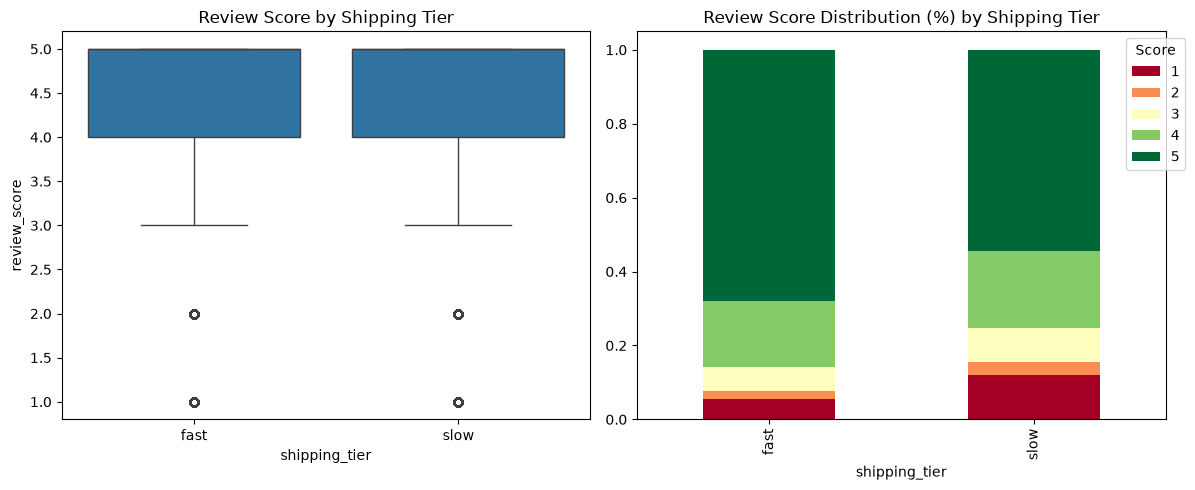

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=stats_df, x="shipping_tier", y="review_score", ax=ax[0], order=["fast", "slow"])
ax[0].set_title("Review Score by Shipping Tier")

stats_df.groupby("shipping_tier")["review_score"].value_counts(normalize=True).unstack().reindex(["fast","slow"]).plot(
    kind="bar", stacked=True, ax=ax[1], colormap="RdYlGn"
)
ax[1].set_title("Review Score Distribution (%) by Shipping Tier")
ax[1].legend(title="Score", bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()


## Phase 2: A/B Testing Simulation — Fast vs. Slow Shipping

**Framing note:** This is an *observational natural-experiment analysis*, not 
a true randomized controlled trial. Customers were not randomly assigned to 
shipping speed — delivery time is influenced by confounding factors (seller 
location, product category, carrier logistics, etc.) not captured here. This 
analysis demonstrates hypothesis-testing methodology and quantifies an 
association, not a causal claim.

**Hypothesis:**
- H0: There is no difference in mean review score between fast (≤7 days) and 
  slow (>7 days) shipping tiers
- H1: There is a difference in mean review score between the two tiers

**Groups:**
- Fast shipping (≤7 days): n = 33,685, mean review score = 4.41
- Slow shipping (>7 days): n = 62,674, mean review score = 4.02

**Test:** Welch's t-test (does not assume equal variances, appropriate given 
unequal group sizes and variances)
- t = 48.57, p < 0.001 → reject H0

**Effect size:** Cohen's d = 0.32 (small-to-moderate effect)

**Interpretation:** The difference in review scores between fast and slow 
shipping tiers is statistically significant and directionally consistent 
with Phase 1's correlation findings, but the effect size is modest — shipping 
speed is one contributing factor to customer satisfaction, not the dominant 
driver. Given the observational nature of this comparison, causal claims 
("faster shipping *causes* higher satisfaction") should be avoided in favor 
of associational language.


In [13]:
customers = pd.read_csv(os.path.join(DATA_PATH, "customers_clean.csv"))
payments = pd.read_csv(os.path.join(DATA_PATH, "order_payments_clean.csv"))

print("customers shape:", customers.shape)
print("payments shape:", payments.shape)
customers.head()


customers shape: (99441, 5)
payments shape: (103886, 5)


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [14]:
# Merge orders with customers to get customer_unique_id
orders_customers = orders.merge(customers[["customer_id", "customer_unique_id"]], on="customer_id", how="left")

# Merge with payments (an order can have multiple payment rows, e.g. split payments — sum them per order first)
order_payment_totals = payments.groupby("order_id")["payment_value"].sum().reset_index()
orders_full = orders_customers.merge(order_payment_totals, on="order_id", how="left")

# Use only delivered orders with valid purchase dates for RFM (undelivered orders shouldn't count toward "engaged" behavior)
rfm_base = orders_full[orders_full["order_status"] == "delivered"].copy()

# Set snapshot date = one day after the most recent purchase in the dataset
snapshot_date = rfm_base["order_purchase_timestamp"].max() + pd.Timedelta(days=1)

rfm = rfm_base.groupby("customer_unique_id").agg(
    recency=("order_purchase_timestamp", lambda x: (snapshot_date - x.max()).days),
    frequency=("order_id", "nunique"),
    monetary=("payment_value", "sum")
).reset_index()

print("RFM table shape:", rfm.shape)
print("\nFrequency distribution:")
print(rfm["frequency"].value_counts().sort_index().head(10))
rfm.describe()


RFM table shape: (93358, 4)

Frequency distribution:
frequency
1     90557
2      2573
3       181
4        28
5         9
6         5
7         3
9         1
15        1
Name: count, dtype: int64


,recency,frequency,monetary
count,93358.000000,93358.000000,93358.000000
mean,237.941773,1.033420,165.197003
std,152.591453,0.209097,226.314012
min,1.000000,1.000000,0.000000
25%,114.000000,1.000000,63.052500
50%,219.000000,1.000000,107.780000
75%,346.000000,1.000000,182.557500
max,714.000000,15.000000,13664.080000


In [15]:
from sklearn.preprocessing import StandardScaler

rfm["monetary_log"] = np.log1p(rfm["monetary"])  # log1p handles the R$0 cases safely

features = rfm[["recency", "frequency", "monetary_log"]]

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(features)

print("Scaled feature means (should be ~0):", rfm_scaled.mean(axis=0))
print("Scaled feature stds (should be ~1):", rfm_scaled.std(axis=0))


Scaled feature means (should be ~0): [-2.34417150e-17 -1.90273660e-18 -9.78767709e-17]
Scaled feature stds (should be ~1): [1. 1. 1.]


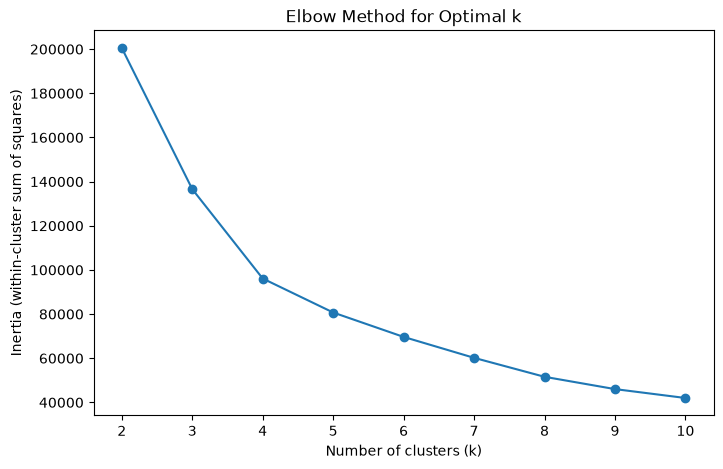

In [16]:
from sklearn.cluster import KMeans

inertias = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (within-cluster sum of squares)")
plt.title("Elbow Method for Optimal k")
plt.xticks(list(k_range))
plt.show()


k=2: silhouette score = 0.6911
k=3: silhouette score = 0.3558
k=4: silhouette score = 0.3672
k=5: silhouette score = 0.3522
k=6: silhouette score = 0.3425
k=7: silhouette score = 0.3449
k=8: silhouette score = 0.3579
k=9: silhouette score = 0.3485
k=10: silhouette score = 0.3488


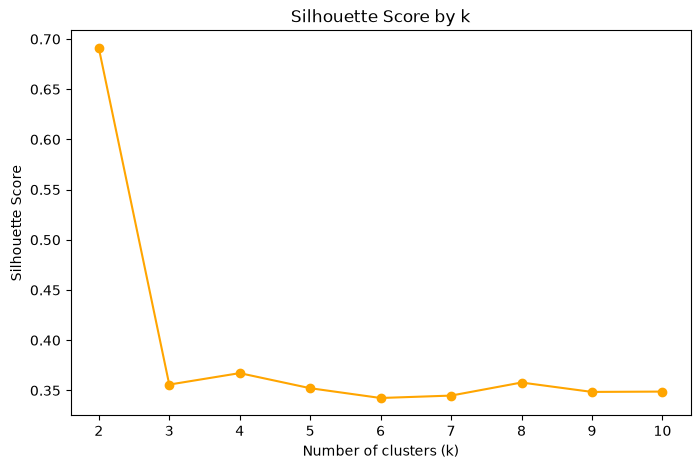

In [17]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(rfm_scaled)
    score = silhouette_score(rfm_scaled, labels)
    silhouette_scores.append(score)
    print(f"k={k}: silhouette score = {score:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), silhouette_scores, marker="o", color="orange")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score by k")
plt.xticks(list(range(2, 11)))
plt.show()


In [20]:
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm["cluster"] = kmeans_final.fit_predict(rfm_scaled)

# Cluster sizes
print("Cluster sizes:")
print(rfm["cluster"].value_counts().sort_index())

# Cluster profiles - mean of raw (unscaled) RFM values per cluster
cluster_profile = rfm.groupby("cluster")[["recency", "frequency", "monetary"]].mean().round(2)
print("\nCluster profiles (mean values):")
print(cluster_profile)


Cluster sizes:
cluster
0    27589
1    35751
2     2801
3    27217
Name: count, dtype: int64

Cluster profiles (mean values):
         recency  frequency  monetary
cluster                              
0         174.42       1.00    320.52
1         146.55       1.00     69.52
2         220.29       2.11    308.59
3         424.19       1.00    118.67


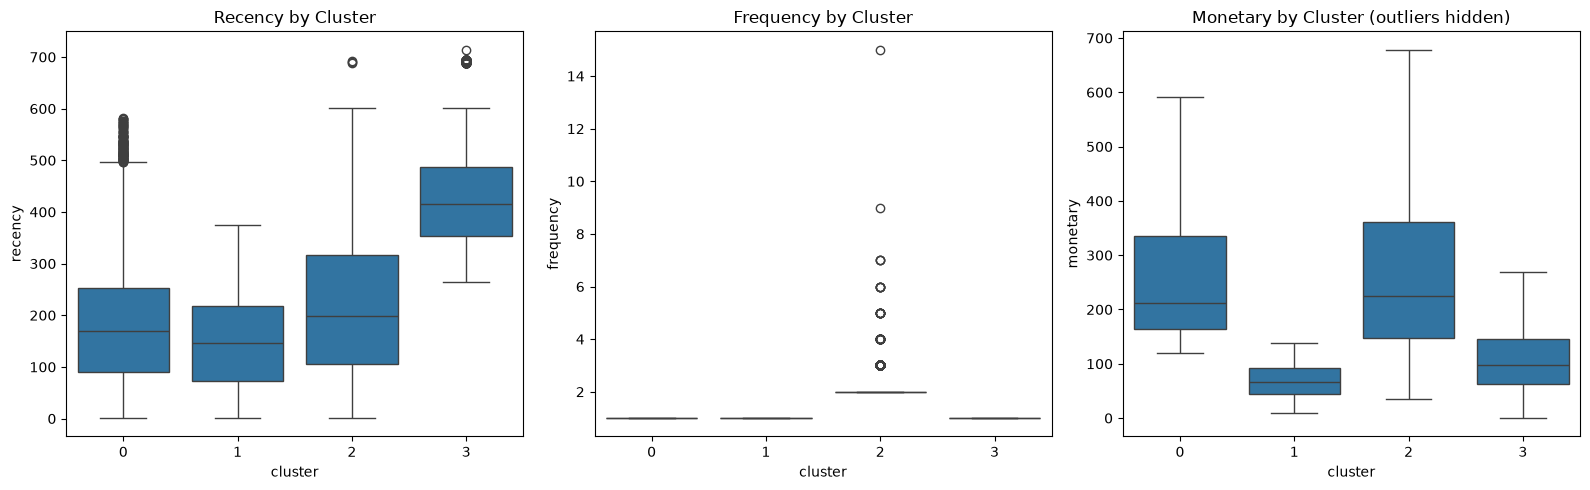

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.boxplot(data=rfm, x="cluster", y="recency", ax=axes[0])
axes[0].set_title("Recency by Cluster")

sns.boxplot(data=rfm, x="cluster", y="frequency", ax=axes[1])
axes[1].set_title("Frequency by Cluster")

sns.boxplot(data=rfm, x="cluster", y="monetary", ax=axes[2], showfliers=False)
axes[2].set_title("Monetary by Cluster (outliers hidden)")

plt.tight_layout()
plt.show()


## Phase 3: Customer Segmentation — RFM + K-Means

**Important caveat:** Olist's dataset shows 97% of customers (90,557 of 93,358) 
made only a single purchase. This is a structural feature of the platform 
(multi-seller marketplace, low repeat-purchase behavior on the platform level) 
rather than a data quality issue. As a result, Frequency contributes minimal 
separating signal to segmentation except for identifying the small repeat-buyer 
group — this is stated explicitly rather than treated as a limitation to hide.

**Method:**
- RFM computed per `customer_unique_id` (not `customer_id`, which is per-order 
  in this dataset) using delivered orders only
- Monetary log-transformed to reduce right-skew before scaling (max value 
  R$13,664 vs. 75th percentile of R$183)
- Features standardized (StandardScaler) prior to clustering, since K-Means 
  relies on Euclidean distance
- k selected via silhouette score across k=2–10. k=2 scored highest (0.69) 
  but was rejected as trivial — it merely re-detects the one-time vs. repeat 
  buyer split already known from the frequency distribution. k=4 (0.367) was 
  selected as the best-performing option among more granular, business-useful 
  cluster counts

**Segments identified:**

| Segment | Size | Recency | Frequency | Monetary | Profile |
|---|---|---|---|---|---|
| Recent High-Spenders | 27,589 (30%) | 174 days | 1.0 | R$320.52 | High-value first-time buyers |
| Recent Low-Spenders | 35,751 (38%) | 147 days | 1.0 | R$69.52 | Low-value first-time buyers |
| Repeat Customers | 2,801 (3%) | 220 days | 2.11 | R$308.59 | Only meaningful repeat-buyer group; high value |
| Dormant/Lapsed | 27,217 (29%) | 424 days | 1.0 | R$118.67 | Over a year since last purchase |

**Business implication:** Repeat Customers, while just 3% of the base, spend 
comparably to the best one-time buyers — a natural retention/loyalty priority. 
Dormant customers (29% of the base) represent the largest recency gap and are 
candidates for re-engagement campaigns.


In [25]:
# Use delivered orders with valid customer_unique_id (reuse orders_full from Phase 3)
cohort_base = orders_full[orders_full["order_status"] == "delivered"].copy()
cohort_base = cohort_base.dropna(subset=["customer_unique_id", "order_purchase_timestamp"])

# Order month and each customer's first purchase month (cohort)
cohort_base["order_month"] = cohort_base["order_purchase_timestamp"].dt.to_period("M")
cohort_base["cohort_month"] = cohort_base.groupby("customer_unique_id")["order_purchase_timestamp"].transform("min").dt.to_period("M")

# Cohort index = number of months since first purchase
cohort_base["cohort_index"] = (cohort_base["order_month"] - cohort_base["cohort_month"]).apply(lambda x: x.n)

print("Date range:", cohort_base["order_month"].min(), "to", cohort_base["order_month"].max())
print("\nCohort sizes (customers by first-purchase month):")
print(cohort_base.groupby("cohort_month")["customer_unique_id"].nunique())


Date range: 2016-09 to 2018-08

Cohort sizes (customers by first-purchase month):
cohort_month
2016-09       1
2016-10     262
2016-12       1
2017-01     717
2017-02    1628
2017-03    2503
2017-04    2256
2017-05    3451
2017-06    3037
2017-07    3752
2017-08    4057
2017-09    4004
2017-10    4328
2017-11    7060
2017-12    5338
2018-01    6842
2018-02    6288
2018-03    6774
2018-04    6582
2018-05    6506
2018-06    5878
2018-07    5949
2018-08    6144
Freq: M, Name: customer_unique_id, dtype: int64


In [26]:
# Count unique customers per cohort_month x cohort_index
cohort_counts = cohort_base.groupby(["cohort_month", "cohort_index"])["customer_unique_id"].nunique().reset_index()
cohort_pivot = cohort_counts.pivot(index="cohort_month", columns="cohort_index", values="customer_unique_id")

# Retention % = each month's count / that cohort's month-0 (initial) size
cohort_sizes = cohort_pivot[0]
retention_matrix = cohort_pivot.divide(cohort_sizes, axis=0) * 100

print("Retention matrix shape:", retention_matrix.shape)
retention_matrix.round(1)


Retention matrix shape: (23, 20)


cohort_index,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
cohort_month,,,,,,,,,,,,,,,,,,,,
2016-09,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,100.0,NaN,NaN,NaN,NaN,NaN,0.4,NaN,NaN,0.4,NaN,0.4,NaN,0.4,NaN,0.4,NaN,0.4,0.8,0.8
2016-12,100.0,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,100.0,0.3,0.3,0.1,0.4,0.1,0.4,0.1,0.1,NaN,0.4,0.1,0.7,0.4,0.1,0.1,0.3,0.4,0.1,NaN
2017-02,100.0,0.2,0.3,0.1,0.4,0.1,0.2,0.2,0.1,0.2,0.1,0.3,0.1,0.2,0.1,0.1,0.1,0.2,NaN,NaN
2017-03,100.0,0.4,0.4,0.4,0.4,0.2,0.2,0.3,0.3,0.1,0.4,0.1,0.2,0.1,0.2,0.2,0.1,0.1,NaN,NaN
2017-04,100.0,0.6,0.2,0.2,0.3,0.3,0.4,0.3,0.3,0.2,0.3,0.1,0.0,0.0,0.1,0.1,0.1,NaN,NaN,NaN
2017-05,100.0,0.5,0.5,0.3,0.3,0.3,0.4,0.1,0.3,0.3,0.3,0.3,0.2,0.0,0.2,0.2,NaN,NaN,NaN,NaN
2017-06,100.0,0.5,0.4,0.4,0.3,0.4,0.4,0.2,0.1,0.2,0.3,0.4,0.2,0.2,0.2,NaN,NaN,NaN,NaN,NaN


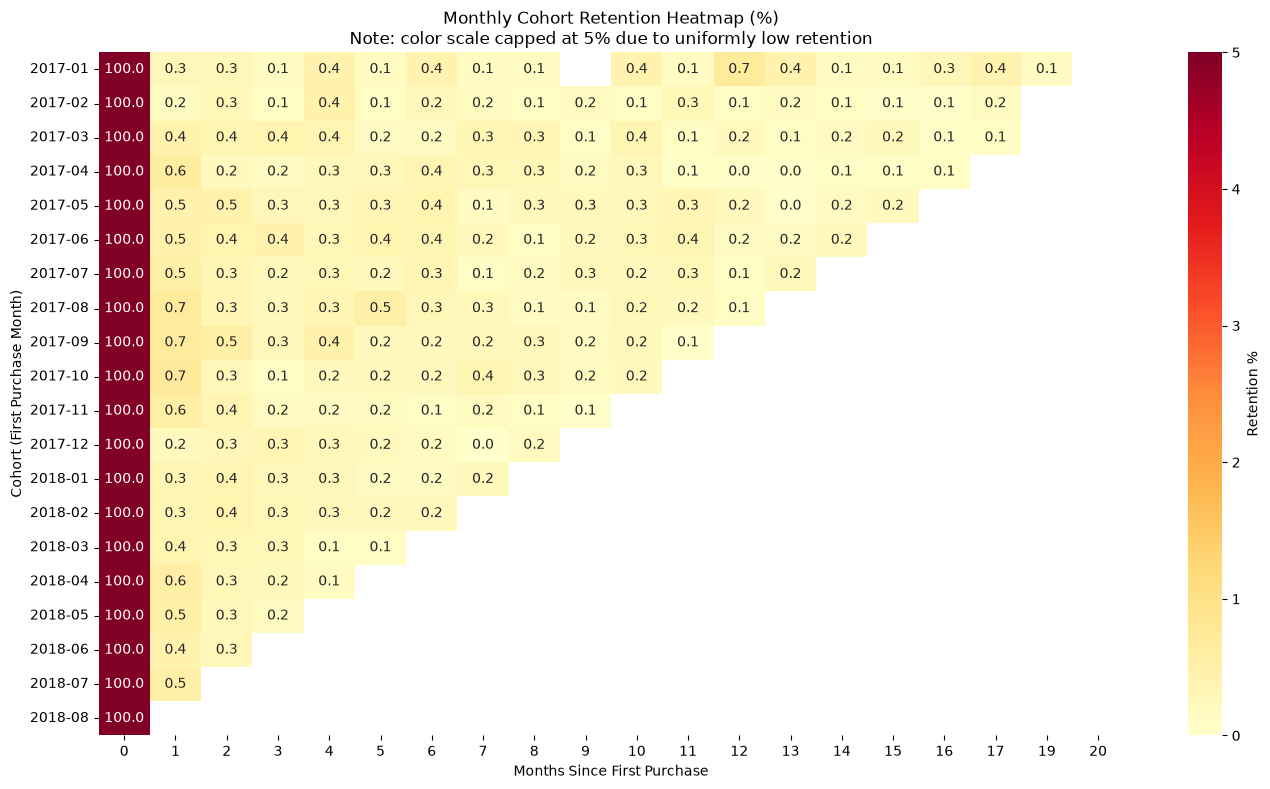

In [27]:
# Drop the tiny unreliable early cohorts
retention_clean = retention_matrix.drop(index=["2016-09", "2016-10", "2016-12"], errors="ignore")

plt.figure(figsize=(14, 8))
sns.heatmap(retention_clean, annot=True, fmt=".1f", cmap="YlOrRd", vmin=0, vmax=5, 
            cbar_kws={"label": "Retention %"})
plt.title("Monthly Cohort Retention Heatmap (%)\nNote: color scale capped at 5% due to uniformly low retention")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Cohort (First Purchase Month)")
plt.tight_layout()
plt.show()


## Phase 4: Cohort Analysis — Monthly Retention

**Method:** Customers grouped into cohorts by month of first purchase 
(`customer_unique_id`, delivered orders only). Retention tracked as % of 
each cohort's original size still placing orders in subsequent months. 
Three early cohorts (Sept, Oct, Dec 2016) excluded from analysis due to 
negligible size (1-2 customers), which produced misleading percentage swings.

**Finding:** Month-1 retention across every cohort (Jan 2017 – Aug 2018) 
stays below 1%, and retention never exceeds ~0.7% at any point in any 
cohort's lifetime. This is dramatically below typical e-commerce benchmarks 
(often 20-40% month-1 retention) and is consistent with the RFM finding 
from Phase 3: Olist customers overwhelmingly purchase once and do not return 
to the platform.

**Interpretation:** This isn't cohort-to-cohort variation worth optimizing — 
it's a structurally flat, uniformly low retention floor across the entire 
observed period (no cohort meaningfully outperforms another). This is 
consistent with Olist's business model as a multi-seller marketplace: 
customers likely form loyalty to individual sellers or products, not to 
the platform itself, so platform-level repeat-purchase behavior stays low 
regardless of when a customer joined.

**Visualization note:** Heatmap color scale deliberately capped at 5% 
(rather than the full 0-100% range) — without capping, the near-uniform 
low retention would render as a single flat color, hiding real (if small) 
differences between cohorts and months.


order_month
2016-10      46566.71
2016-12         19.62
2017-01     127545.67
2017-02     271298.65
2017-03     414369.39
2017-04     390952.18
2017-05     567066.73
2017-06     490225.60
2017-07     566403.93
2017-08     646000.61
2017-09     701169.99
2017-10     751140.27
2017-11    1153528.05
2017-12     843199.17
2018-01    1078606.86
2018-02     966510.88
2018-03    1120678.00
2018-04    1132933.95
2018-05    1128836.69
2018-06    1012090.68
2018-07    1027903.86
2018-08     985414.28
Freq: M, Name: payment_value, dtype: float64


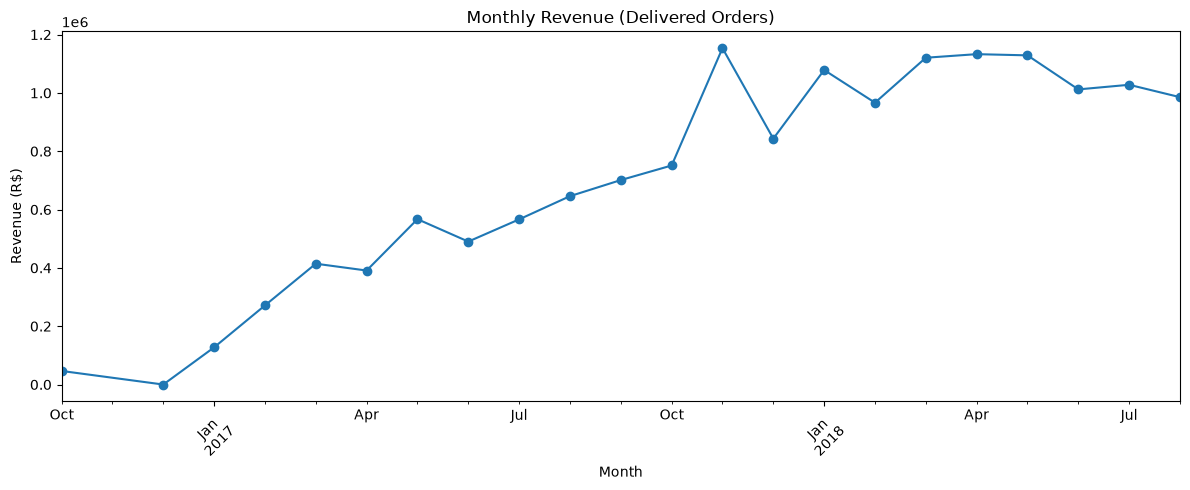

In [28]:
# Aggregate total revenue by order month (using delivered orders + payment totals)
revenue_base = orders_full[orders_full["order_status"] == "delivered"].dropna(subset=["order_purchase_timestamp", "payment_value"])
revenue_base["order_month"] = revenue_base["order_purchase_timestamp"].dt.to_period("M")

monthly_revenue = revenue_base.groupby("order_month")["payment_value"].sum()

print(monthly_revenue)

plt.figure(figsize=(12, 5))
monthly_revenue.plot(marker="o")
plt.title("Monthly Revenue (Delivered Orders)")
plt.ylabel("Revenue (R$)")
plt.xlabel("Month")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [29]:
# Check the actual date range of raw purchase timestamps to see if Aug 2018 is complete
print("Latest purchase timestamp in dataset:", orders["order_purchase_timestamp"].max())

# Trim to Jan 2017 onward (drop the two trivial 2016 months)
revenue_series = monthly_revenue["2017-01":]
print("\nTrimmed series length:", len(revenue_series))
revenue_series


Latest purchase timestamp in dataset: 2018-10-17 17:30:18

Trimmed series length: 20


order_month
2017-01     127545.67
2017-02     271298.65
2017-03     414369.39
2017-04     390952.18
2017-05     567066.73
2017-06     490225.60
2017-07     566403.93
2017-08     646000.61
2017-09     701169.99
2017-10     751140.27
2017-11    1153528.05
2017-12     843199.17
2018-01    1078606.86
2018-02     966510.88
2018-03    1120678.00
2018-04    1132933.95
2018-05    1128836.69
2018-06    1012090.68
2018-07    1027903.86
2018-08     985414.28
Freq: M, Name: payment_value, dtype: float64

In [30]:
order_counts = revenue_base.groupby("order_month")["order_id"].nunique()
print(order_counts.tail(6))


order_month
2018-03    7003
2018-04    6798
2018-05    6749
2018-06    6099
2018-07    6159
2018-08    6351
Freq: M, Name: order_id, dtype: int64


In [31]:
from statsmodels.tsa.holtwinters import Holt

# Convert PeriodIndex to a proper datetime index for statsmodels
revenue_series.index = revenue_series.index.to_timestamp()

# Fit Holt's linear trend model
model = Holt(revenue_series, initialization_method="estimated")
fit = model.fit(optimized=True)

# Forecast next 6 months
forecast = fit.forecast(6)

print("Model parameters:")
print(f"Smoothing level (alpha): {fit.params['smoothing_level']:.4f}")
print(f"Smoothing trend (beta): {fit.params['smoothing_trend']:.4f}")

print("\nForecast (next 6 months):")
print(forecast)


Model parameters:
Smoothing level (alpha): 0.4081
Smoothing trend (beta): 0.4081

Forecast (next 6 months):
2018-09-01    1.006435e+06
2018-10-01    9.767333e+05
2018-11-01    9.470315e+05
2018-12-01    9.173297e+05
2019-01-01    8.876279e+05
2019-02-01    8.579260e+05
Freq: MS, dtype: float64


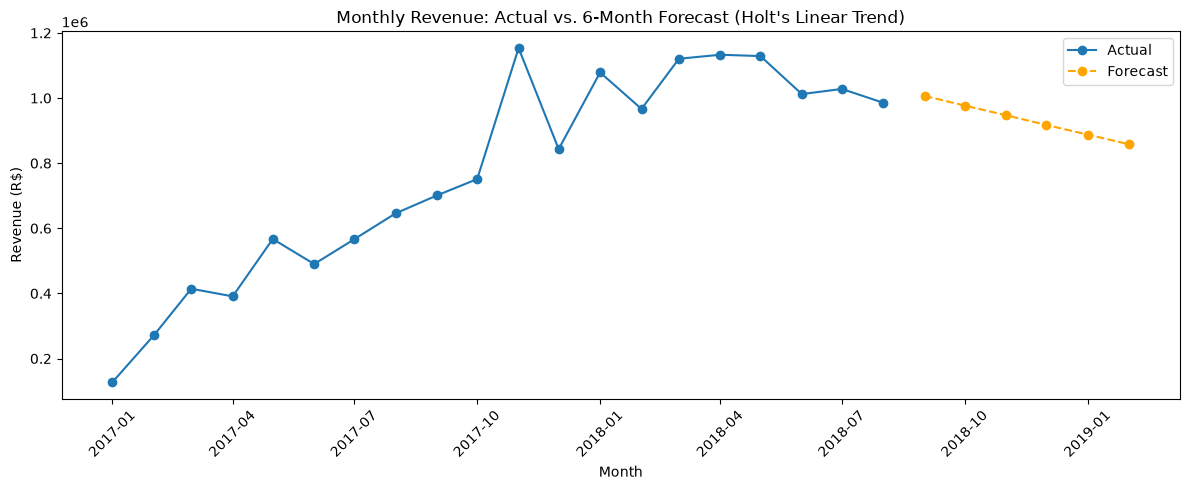

In [32]:
plt.figure(figsize=(12, 5))
plt.plot(revenue_series.index, revenue_series.values, marker="o", label="Actual")
plt.plot(forecast.index, forecast.values, marker="o", linestyle="--", color="orange", label="Forecast")
plt.title("Monthly Revenue: Actual vs. 6-Month Forecast (Holt's Linear Trend)")
plt.ylabel("Revenue (R$)")
plt.xlabel("Month")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Phase 5 (Stretch): Light Forecasting — Exponential Smoothing

**Method:** Holt's linear trend exponential smoothing, applied to monthly 
revenue (Jan 2017 – Aug 2018, 20 months). ARIMA was considered but rejected: 
with only 20 months of data, reliably estimating seasonal terms (needed for 
SARIMA) isn't feasible, and the visible Nov 2017 spike (Black Friday) makes 
clear seasonality exists but can't be properly modeled with this history length.

**Data completeness check:** Order volume for Aug 2018 (6,351 orders) was 
verified as consistent with June/July 2018, confirming no delivery-lag 
truncation before including it in the series. The two near-empty 2016 months 
(Oct: R$47K from 1 customer, Dec: R$20) were excluded as non-representative.

**Result:** The model forecasts a gradual revenue decline from ~R$1.01M 
(Sep 2018) to ~R$858K (Feb 2019).

**Critical assessment — this forecast should be treated with caution:** 
Visually, the model appears to be extrapolating the minor Jun-Aug 2018 dip 
into a sustained downward trend, when the broader Mar-Aug 2018 pattern looks 
more like oscillation around a R$1.0-1.15M plateau than genuine decline. 
Holt's method has no mechanism to distinguish short-term noise from real 
trend change, and with only 20 data points, no train-test holdout validation 
was performed to check forecast accuracy against held-out actuals.

**Conclusion:** This phase demonstrates exponential smoothing methodology 
and its practical limitations on short time series, rather than delivering 
a production-grade revenue forecast. A real deployment would need (a) more 
historical data, (b) a seasonal model once enough history exists, and (c) 
backtesting against holdout periods before trusting directional forecasts.
